GPU Available: True
Image size: (256, 256)
Image mode: RGB


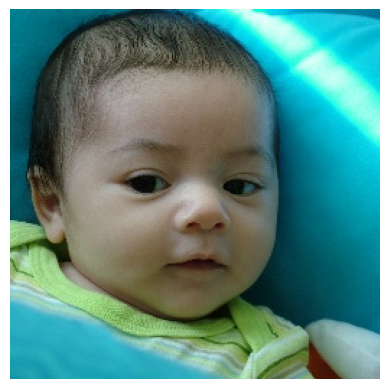

In [2]:
import torch
import os
from PIL import Image
import matplotlib.pyplot as plt

print("GPU Available:", torch.cuda.is_available())

# Sample image dekho
sample_path = r"D:\Deep Fake Detection\dataset\real_vs_fake\real-vs-fake\train\real"
sample_img = os.listdir(sample_path)[0]
img = Image.open(os.path.join(sample_path, sample_img))
print("Image size:", img.size)
print("Image mode:", img.mode)
plt.imshow(img)
plt.axis('off')
plt.show()

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Image transformations: resize, tensor conversion, normalization
transform = transforms.Compose([
    transforms.Resize((128, 128)),   # 256x256 se chota karke training fast karenge
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Dataset paths
base_path = r"D:\Deep Fake Detection\dataset\real_vs_fake\real-vs-fake"

train_data = datasets.ImageFolder(root=base_path + r"\train", transform=transform)
valid_data = datasets.ImageFolder(root=base_path + r"\valid", transform=transform)
test_data  = datasets.ImageFolder(root=base_path + r"\test", transform=transform)

# DataLoaders - batch mein data feed karne ke liye
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0)

# Class labels check karo
print("Classes:", train_data.classes)
print("Class to index mapping:", train_data.class_to_idx)
print("Total train batches:", len(train_loader))
print("Total valid batches:", len(valid_loader))
print("Total test batches:", len(test_loader))

Classes: ['fake', 'real']
Class to index mapping: {'fake': 0, 'real': 1}
Total train batches: 1563
Total valid batches: 313
Total test batches: 313


In [4]:
import torch.nn.functional as F

class DeepfakeCNN(nn.Module):
    def __init__(self):
        super(DeepfakeCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(256)
        
        # 128x128 -> after 4 pooling layers (each /2) -> 8x8
        self.fc1 = nn.Linear(256 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 2)   # 2 classes: real, fake
        
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 128 -> 64
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 64 -> 32
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # 32 -> 16
        x = self.pool(F.relu(self.bn4(self.conv4(x))))   # 16 -> 8
        
        x = x.view(x.size(0), -1)   # flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Model ko GPU pe bhejo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepfakeCNN().to(device)
print(model)
print("\nModel is on:", device)

DeepfakeCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=16384, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Mo

In [9]:
model = DeepfakeCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [10]:
from tqdm import tqdm
import time

train_losses, train_accuracies = [], []
valid_losses, valid_accuracies = [], []

num_epochs = 10

for epoch in range(num_epochs):
    start_time = time.time()
    
    # ---- TRAINING ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # ---- VALIDATION ----
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Valid]"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    valid_loss = val_running_loss / len(valid_loader)
    valid_acc = 100 * val_correct / val_total
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_acc)
    
    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {valid_loss:.4f}, Val Acc: {valid_acc:.2f}% | Time: {epoch_time:.1f}s")

Epoch 1/10 [Valid]: 100%|██████████| 313/313 [01:00<00:00,  5.17it/s]


Epoch [1/10] | Train Loss: 0.6229, Train Acc: 64.71% | Val Loss: 0.4716, Val Acc: 79.23% | Time: 374.3s


Epoch 2/10 [Valid]: 100%|██████████| 313/313 [00:53<00:00,  5.88it/s]


Epoch [2/10] | Train Loss: 0.3618, Train Acc: 84.35% | Val Loss: 0.2767, Val Acc: 89.91% | Time: 346.7s


Epoch 3/10 [Valid]: 100%|██████████| 313/313 [00:45<00:00,  6.85it/s]


...

Epoch [8/10] | Train Loss: 0.0503, Train Acc: 98.13% | Val Loss: 0.0760, Val Acc: 97.55% | Time: 285.8s


Epoch 9/10 [Valid]: 100%|██████████| 313/313 [00:45<00:00,  6.89it/s]


Epoch [9/10] | Train Loss: 0.0450, Train Acc: 98.42% | Val Loss: 0.0731, Val Acc: 97.50% | Time: 296.7s


Epoch 10/10 [Valid]: 100%|██████████| 313/313 [00:45<00:00,  6.88it/s]

Epoch [10/10] | Train Loss: 0.0363, Train Acc: 98.64% | Val Loss: 0.0690, Val Acc: 97.38% | Time: 293.6s


In [11]:
torch.save(model.state_dict(), r"D:\Deep Fake Detection\model_checkpoint.pth")
print("Model saved successfully!")

Model saved successfully!


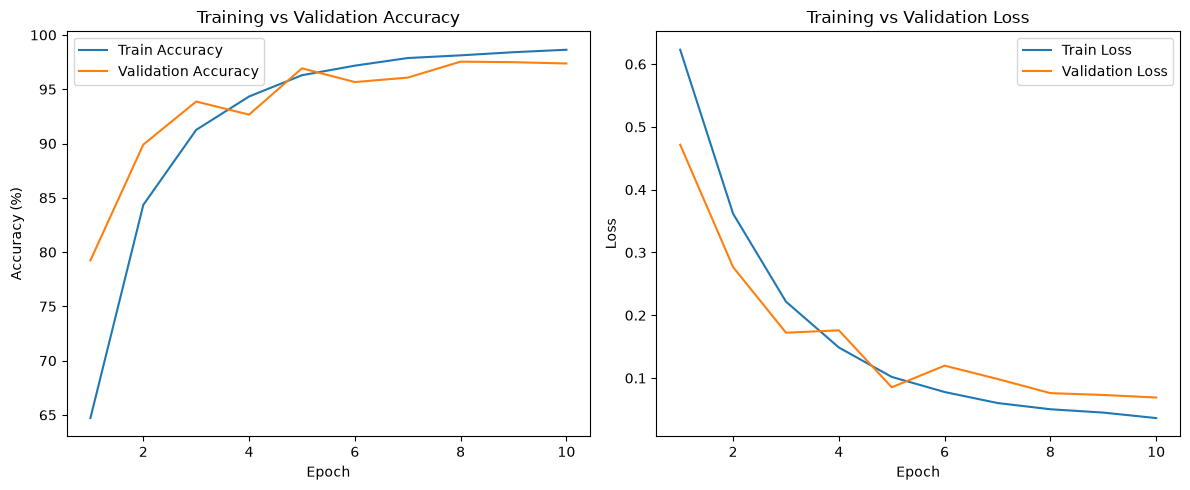

In [12]:
import matplotlib.pyplot as plt

epochs_range = range(1, 11)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, valid_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.savefig(r"D:\Deep Fake Detection\training_curves.png")
plt.show()

Testing: 100%|██████████| 313/313 [01:09<00:00,  4.51it/s]



Final Test Accuracy: 97.48%



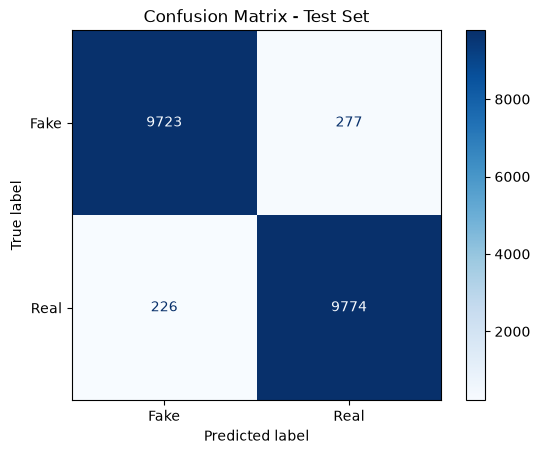

              precision    recall  f1-score   support

        Fake       0.98      0.97      0.97     10000
        Real       0.97      0.98      0.97     10000

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



In [13]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Test Accuracy
test_acc = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%\n")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.savefig(r"D:\Deep Fake Detection\confusion_matrix.png")
plt.show()

# Classification Report (Precision, Recall, F1-score)
print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

In [14]:
torch.save(model.state_dict(), r"D:\Deep Fake Detection\model_checkpoint.pth")
print("Model saved!")

Model saved!
